# Lab 3: Exploring Arizona Census Demographics using **numpy** and **pandas**

This notebook walks through a small data analysis using Arizona ZIP-code level ACS data and a secondary table (COVID vaccinations by ZIP).
Each code cell is paired with explanatory Markdown that 'shadows' the code: it explains what the code does and why. In addition, the code contains inline comments beside each line so that if a line is removed, students can re-write it from the hint.

High-level steps:
- Load required packages
- Read and inspect the ACS CSV (census by ZIP)
- Create a POSTCODE key and compute summary statistics
- Read a secondary dataset (vaccinations by ZIP), clean and merge
- Compute vaccination rate, visualize, and run a linear regression
- Explore distributions and interpret results

## Packages

Import the Python packages used in the notebook. The comments in the code cell explain the purpose of each import so you can re-create a removed line.

Notes:
- NumPy for numeric arrays; pandas for tables (DataFrames).
- Matplotlib for static plots; Plotly and Seaborn for nicer/interactive visualizations.
- SciPy for statistical tests and linear regression.

In [2]:
import numpy as np  # numerical arrays and math functions (alias np)
import pandas as pd  # DataFrame and CSV I/O (alias pd)
import matplotlib.pyplot as plt  # plotting (alias plt)
import plotly.express as px  # optional: interactive plotting (alias px)
from scipy import stats  # statistical functions (e.g., linregress)

# Configure matplotlib for inline display
%matplotlib inline

## 1. Acquire the ACS data

Read the Arizona ACS CSV (ZIP-code level). The code cell below loads the CSV into a pandas DataFrame named `df_census_zips` and previews the first rows so you can confirm column names and data types.

The dataset we will use is a CSV file containing 2023 American Community Survey (ACS) data collected by the U.S. Census Bureau, representing the latest available 5-year ACS estimates as of October 2025. This data set provides various demographic details for Arizona's Zip Code Tabulation Areas (ZCTAs). To analyze the data, we will import it into a pandas DataFrame named `df_census_zips` using `pd.read_csv`. The data originates from the Arizona Geographic Information Council, which maintains an extensive open data portal at [https://azgeo-data-hub-agic.hub.arcgis.com/](https://azgeo-data-hub-agic.hub.arcgis.com/). You can visit their "data" section and search for "ACS zip codes," or directly access the Zip Code layer using this shortcut: [https://azgeo-open-data-agic.hub.arcgis.com/datasets/AZMAG::arizona-american-community-survey-2023/explore?layer=11](https://azgeo-open-data-agic.hub.arcgis.com/datasets/AZMAG::arizona-american-community-survey-2023/explore?layer=11). Simply download the CSV file and load it as `df_census_zips` for your analysis.

[1](https://azgeo-open-data-agic.hub.arcgis.com/datasets/AZMAG::arizona-american-community-survey-2023/explore?layer=11&location=34.234589%2C-111.876066%2C7.70)

In [3]:
# Replace the filename below with the path to your downloaded ACS CSV
# Example: df_census_zips = pd.read_csv('Arizona_ACS_2023.csv')
df_census_zips = pd.read_csv('Arizona_ACS_2023.csv')  # read ACS CSV into DataFrame

# Preview the first few rows to inspect columns and sample values
df_census_zips.head()  # shows first 5 rows

,OBJECTID,GEOID20,NAME,SUMLEVEL,TOTAL_POP,MALE,PCT_MALE,FEMALE,PCT_FEMALE,MEDIAN_AGE,...,THREE_PLUS_VEHICLES,PCT_THREE_PLUS_VEHICLES,CIV_NONINST_POP,DISABILITY,PCT_DISABILITY,ACRES,SQMI,POP_PER_SQMI,Shape__Area,Shape__Length
0,1,84531,84531,860,640,368,57.500000,272,42.500000,27.4,...,48,27.272727,640,120,18.750000,175534.749179,274.273319,2.333439,1.117115e+09,322590.388114
1,2,84536,84536,860,1391,677,48.670022,714,51.329978,31.8,...,73,18.911917,1391,337,24.227175,367235.746075,573.806426,2.424162,2.342133e+09,367850.838336
2,3,85003,85003,860,10155,5674,55.873954,4481,44.126046,37.4,...,371,6.819853,9046,1328,14.680522,1190.192993,1.859678,5460.621559,6.938396e+06,21925.668245
3,4,85004,85004,860,11178,5582,49.937377,5596,50.062623,28.1,...,186,3.423523,11169,1266,11.334945,1313.341364,2.052098,5447.108467,7.656501e+06,20731.212284
4,5,85006,85006,860,22081,11106,50.296635,10975,49.703365,33.7,...,1471,16.275725,21911,2729,12.454931,2539.466061,3.967920,5564.880792,1.480913e+07,18633.396525


In [4]:
# Check the data types of each column
df_census_zips.dtypes

OBJECTID           int64
GEOID20            int64
NAME               int64
SUMLEVEL           int64
TOTAL_POP          int64
                  ...   
ACRES            float64
SQMI             float64
POP_PER_SQMI     float64
Shape__Area      float64
Shape__Length    float64
Length: 306, dtype: object

### Create a ZIP code key

Create a new column called `POSTCODE` from whichever field stores the ZIP code in your dataset. After creating the new column, use `.astype(str)` to ensure the datatype is `object` (string).

In [5]:
# Create POSTCODE from the existing ZIP column and use astype to ensure string type
df_census_zips['POSTCODE'] = df_census_zips['NAME'].astype(str)

# Inspect the DataFrame structure
df_census_zips.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 420 entries, 0 to 419
Data columns (total 307 columns):
 #    Column                           Dtype  
---   ------                           -----  
 0    OBJECTID                         int64  
 1    GEOID20                          int64  
 2    NAME                             int64  
 3    SUMLEVEL                         int64  
 4    TOTAL_POP                        int64  
 5    MALE                             int64  
 6    PCT_MALE                         float64
 7    FEMALE                           int64  
 8    PCT_FEMALE                       float64
 9    MEDIAN_AGE                       float64
 10   UNDER5                           int64  
 11   PCT_UNDER5                       float64
 12   AGE5TO9                          int64  
 13   PCT_AGE5TO9                      float64
 14   AGE10TO14                        int64  
 15   PCT_AGE10TO14                    float64
 16   AGE15TO19                        int64  
 

### Compute summary statistics

Use pandas operations to compute statistics that summarize your data.  For example:

* The total population across all ZIP codes: `df_name['column_name'].sum()`
* The median population of females: `df_name['column_name'].median()`
* The mean household income: `df_name['column_name'].mean()`

Feel free to explore other interesting columns.

In [7]:
# TODO: compute some summary statistics
total_population = df_census_zips['TOTAL_POP'].sum() # Total population can be calculated by summing the 'TOTAL_POP' column
median_female_pop = df_census_zips['FEMALE'].median() # Median female population can be calculated using the median of the 'FEMALE' column
mean_income = df_census_zips['MEDIAN_HOUSEHOLD_INCOME'].mean() # Mean household income can be calculated using the mean of the 'MEDIAN_HOUSEHOLD_INCOME' column

# Do not change the print statements below
print("Total population:", total_population)
print("Median female population:", f"{np.ceil(median_female_pop):.0f}")
print("Mean household income:", f"{mean_income:.2f}")

Total population: 7274838
Median female population: 4160
Mean household income: 69406.44


## 2. Acquire a secondary demographic dataset

The next dataset is from https://www.azdhs.gov/. They have Covid-19 vaccinations by zip code. The data can be downloaded from their ArcGIS page: https://adhsgis.maps.arcgis.com/sharing/rest/content/items/18f3f6041050465a8eccfa5b9625d608/data. Use pd.read_excel() to download the data as a dataframe named df_covid_zip. You can download the data to your computer and then read the file, or you can directly use pd.read_excel to download from 'https://adhsgis.maps.arcgis.com/sharing/rest/content/items/18f3f6041050465a8eccfa5b9625d608/data'.

Make sure your secondary table has a column containing the ZIP code.

In [8]:
# Replace with your exported file path
filename = r".\Vac_COVID19_BYZIP_excel.csv"
df_covid_zip = pd.read_csv(filename)
# Preview
print(df_covid_zip.head()) # shows first 5 rows

   OBJECTID tribal_status POSTCODE NumberOfPeopleVaccinated  \
0         1    Non-Tribal    85003                     2776   
1         2    Non-Tribal    85004                     2045   
2         3    Non-Tribal    85006                     3437   
3         4    Non-Tribal    85007                     2482   
4         5    Non-Tribal    85008                     6370   

  NumberOfPeopleVaccinatedCategory  Shape_Length    Shape_Area  
0                      1,001-5,000   19678.55802  7.393038e+06  
1                      1,001-5,000   20058.21915  7.215754e+06  
2                      1,001-5,000   19248.57357  1.449081e+07  
3                      1,001-5,000   24443.16669  1.520256e+07  
4                     5,001-10,000   34329.64012  3.762553e+07  


### Merge the datasets

Use `pd.merge()` to combine `df_census_zips` and `df_covid_zip` into a new DataFrame called `df_merged`.

* Merge on the `POSTCODE` column.
* Use an inner join (`how='inner'`) so that only ZIP codes present in both tables are retained.

After merging, preview the first few rows with `.head()`.

In [9]:

# Merge the census and secondary data on POSTCODE
# Syntax: pd.merge(left, right, on=key, how=join_type)
df_merged = pd.merge(df_census_zips, df_covid_zip, on='POSTCODE', how='inner')

# Inspect the merged DataFrame
df_merged.head()

,OBJECTID_x,GEOID20,NAME,SUMLEVEL,TOTAL_POP,MALE,PCT_MALE,FEMALE,PCT_FEMALE,MEDIAN_AGE,...,POP_PER_SQMI,Shape__Area,Shape__Length,POSTCODE,OBJECTID_y,tribal_status,NumberOfPeopleVaccinated,NumberOfPeopleVaccinatedCategory,Shape_Length,Shape_Area
0,3,85003,85003,860,10155,5674,55.873954,4481,44.126046,37.4,...,5460.621559,6.938396e+06,21925.668245,85003,1,Non-Tribal,2776,"1,001-5,000",19678.55802,7.393038e+06
1,4,85004,85004,860,11178,5582,49.937377,5596,50.062623,28.1,...,5447.108467,7.656501e+06,20731.212284,85004,2,Non-Tribal,2045,"1,001-5,000",20058.21915,7.215754e+06
2,5,85006,85006,860,22081,11106,50.296635,10975,49.703365,33.7,...,5564.880792,1.480913e+07,18633.396525,85006,3,Non-Tribal,3437,"1,001-5,000",19248.57357,1.449081e+07
3,6,85007,85007,860,13555,7012,51.729989,6543,48.270011,34.3,...,2933.957854,1.723574e+07,27669.667905,85007,4,Non-Tribal,2482,"1,001-5,000",24443.16669,1.520256e+07
4,7,85008,85008,860,60499,31230,51.620688,29269,48.379312,30.5,...,5887.742032,3.834884e+07,36722.845342,85008,5,Non-Tribal,6370,"5,001-10,000",34329.64012,3.762553e+07


### Clean the merged dataset


Before analyzing the data in detail, let's clean the merged dataset. In the **NumberOfPeopleVaccinated** column, some values are recorded as '1-10' to protect privacy for small counts. Since we can't use these ranges in our calculations, we'll remove those rows. We will also remove the ones which have 'DataSuppressed'. We also need to ensure our dataset excludes very small populations and has complete information for both income and vaccination data to avoid skewing our analysis. This cleaning step helps ensure our subsequent statistical analysis will be reliable and meaningful.

In [ ]:
# Identify rows where the value is a range (1-10) encoded as text and drop them. Also, drop Data Suppressed
df_merged['NumberOfPeopleVaccinated'] = np.where(df_merged['NumberOfPeopleVaccinated'].str.contains('1-10') | df_merged['NumberOfPeopleVaccinated'].str.contains('DataSuppressed'), np.nan, df_merged['NumberOfPeopleVaccinated'])

# The above was partially modified by Copilot. Original code was a for loop and if statement, similar to what was shown in the lecture. It came back as invalid syntax.

# Convert the variable in NumberOfPeopleVaccinated to integer
df_merged['NumberOfPeopleVaccinated'] = df_merged['NumberOfPeopleVaccinated'].astype(float).astype('Int64')

# Remove rows with very small populations
df_merged = df_merged[df_merged['TOTAL_POP'] > 100]

# Drop rows with NaN in MEDIAN_HOUSEHOLD_INCOME or in NumberOfPeopleVaccinated
df_merged = df_merged.dropna(subset=['MEDIAN_HOUSEHOLD_INCOME', 'NumberOfPeopleVaccinated'])

# Confirm the DataFrame looks sensible
df_merged.head()

,OBJECTID_x,GEOID20,NAME,SUMLEVEL,TOTAL_POP,MALE,PCT_MALE,FEMALE,PCT_FEMALE,MEDIAN_AGE,...,POP_PER_SQMI,Shape__Area,Shape__Length,POSTCODE,OBJECTID_y,tribal_status,NumberOfPeopleVaccinated,NumberOfPeopleVaccinatedCategory,Shape_Length,Shape_Area
0,3,85003,85003,860,10155,5674,55.873954,4481,44.126046,37.4,...,5460.621559,6.938396e+06,21925.668245,85003,1,Non-Tribal,2776,"1,001-5,000",19678.55802,7.393038e+06
1,4,85004,85004,860,11178,5582,49.937377,5596,50.062623,28.1,...,5447.108467,7.656501e+06,20731.212284,85004,2,Non-Tribal,2045,"1,001-5,000",20058.21915,7.215754e+06
2,5,85006,85006,860,22081,11106,50.296635,10975,49.703365,33.7,...,5564.880792,1.480913e+07,18633.396525,85006,3,Non-Tribal,3437,"1,001-5,000",19248.57357,1.449081e+07
3,6,85007,85007,860,13555,7012,51.729989,6543,48.270011,34.3,...,2933.957854,1.723574e+07,27669.667905,85007,4,Non-Tribal,2482,"1,001-5,000",24443.16669,1.520256e+07
4,7,85008,85008,860,60499,31230,51.620688,29269,48.379312,30.5,...,5887.742032,3.834884e+07,36722.845342,85008,5,Non-Tribal,6370,"5,001-10,000",34329.64012,3.762553e+07


In [12]:
# Let's create a column of vaccinations as a percentage of the population
df_merged['VaccinationRate'] = df_merged['NumberOfPeopleVaccinated'] / df_merged['TOTAL_POP'] * 100

# Calculate the mean of VaccinationRate for AZ zip codes
mean_vaccination_rate_az = df_merged['VaccinationRate'].mean() 
mean_vaccination_rate_az

20.536007954054497

## 3. Visualize the relationship

Make a scatter plot of `MEDIAN_HOUSEHOLD_INCOME` on the x‑axis and your new percentage variable on the y‑axis.
Use Plotly, call `px.scatter()` and include labels and a title.

In [16]:
# Interactive scatter plot with plotly
# Syntax: px.scatter(data_frame, x='column A', y='column B', labels={'column A': 'Label A', 'column B': 'Label B'}, title='Graph Title')

fig = px.scatter(df_merged, x='MEDIAN_HOUSEHOLD_INCOME', y='VaccinationRate',
           labels={'MEDIAN_HOUSEHOLD_INCOME': 'Median Household Income (USD)', 'VaccinationRate': 'Vaccination Rate (%)'},
           title='COVID-19 Vaccination Rate vs. Median Household Income in Arizona Zip Codes')

# Title and labels generated by Copilot

fig.show()

## 4. Perform a linear regression

Do you think there is a relationship between income and vaccination rate? Convert the `MEDIAN_HOUSEHOLD_INCOME` and `VaccinationRate` columns to NumPy arrays and use `stats.linregress()` to fit a linear regression.  Print the slope, intercept, p‑value and r‑value.  Then compute and print the coefficient of determination \(R^2\).

In [14]:

# Convert to numpy arrays using .to_numpy()
x = df_merged['MEDIAN_HOUSEHOLD_INCOME'].to_numpy()
y = df_merged['VaccinationRate'].to_numpy()

# Perform linear regression using stats.linregress
res = stats.linregress(x, y)

# Print regression parameters
print(f"Slope: {res.slope}") # Slope of the regression line using regressionObject.slope
print(f"Intercept: {res.intercept}") # Intercept of the regression line using regressionObject.intercept
print("The p_value should be less than 0.05 for a significant relation between x and y")
print(f"p-value: {res.pvalue}") # p-value of the regression using regressionObject.pvalue

# Compute and print R-squared
r_squared = res.rvalue ** 2  # Calculate R-squared using regressionObject.rvalue and square it
print(f"R-squared: {r_squared}")

Slope: 0.00017260850633266873
Intercept: 8.037902036244217
The p_value should be less than 0.05 for a significant relation between x and y
p-value: 2.2358376415841258e-13
R-squared: 0.14301265006584302


### Plot the regression line

Overlay the regression line on the scatter plot.  Use Matplotlib for this plot.

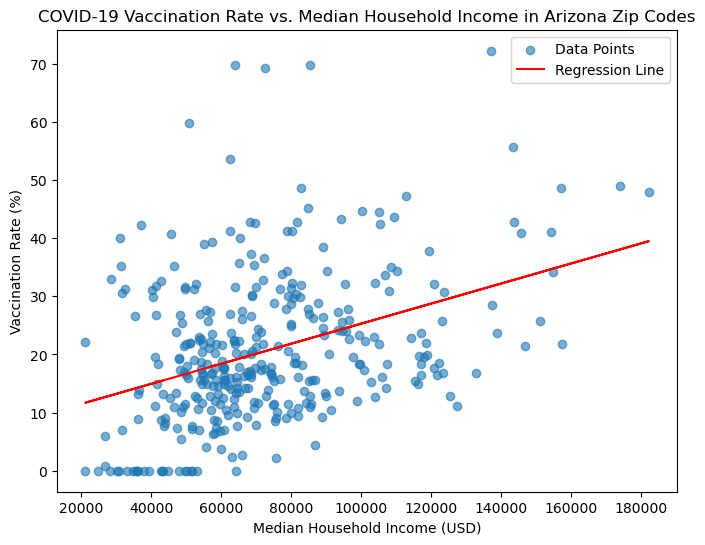

In [15]:
# Plot scatter
 # Set figure size using plt.figure. Values are in inches. Keep height as 6 and width as 8
 # Plot data points with 60% transparency and label using plt.scatter

plt.figure(figsize=(8, 6))
plt.scatter(x, y, alpha=0.6, label='Data Points')
 
# Compute predicted values
 # Compute predicted values using regression parameters and the line equation

predicted_y = res.intercept + res.slope * x

# Plot regression line
  # Plot regression line with color and label
  # Label x-axis using plt.xlabel
  # Label y-axis using plt.ylabel
  # Set plot title using plt.title
  # Show legend using plt.legend
  # Display the plot using plt.show()

plt.plot(x, predicted_y, color='red', label='Regression Line')
plt.xlabel('Median Household Income (USD)')
plt.ylabel('Vaccination Rate (%)')
plt.title('COVID-19 Vaccination Rate vs. Median Household Income in Arizona Zip Codes')
plt.legend()
plt.show()

## 5. Explore distributions

Create histograms of your percentage variable and of median household income using Matplotlib.  Label your axes and include titles.

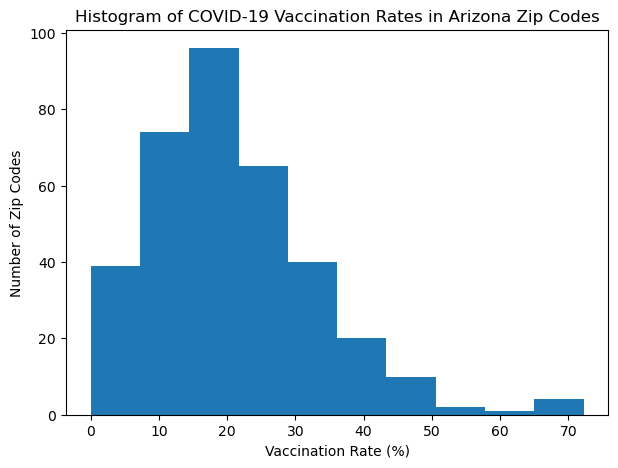

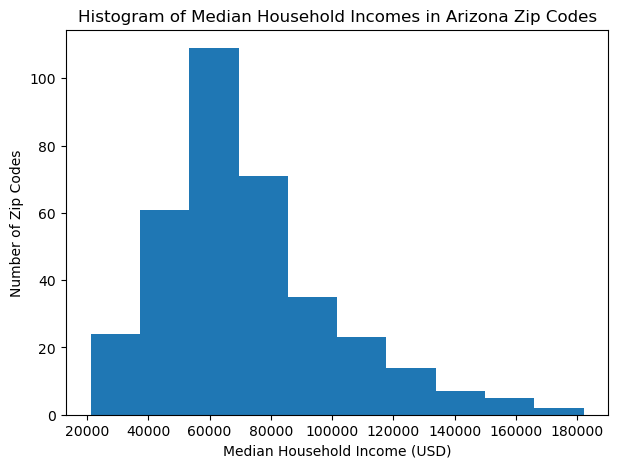

In [17]:
# Histogram of the selected percentage: Vaccination Rate
 # Use plt.figure to set the figure size. Keep the height as 5 and width as 7
 # Use plt.hist to create a histogram
 # Use plt.xlabel to set the x-axis label
 # Use plt.ylabel to set the y-axis label
 # Use plt.title to set the title
 # Use plt.show to display the plot

plt.figure(figsize=(7, 5))
plt.hist(df_merged['VaccinationRate'])
plt.xlabel('Vaccination Rate (%)')
plt.ylabel('Number of Zip Codes')
plt.title('Histogram of COVID-19 Vaccination Rates in Arizona Zip Codes')
plt.show()

# Histogram of median household income
 # Use plt.figure to set the figure size. Keep the height as 5 and width as 7
 # Use plt.hist to create a histogram
 # Use plt.xlabel to set the x-axis label
 # Use plt.ylabel to set the y-axis label
 # Use plt.title to set the title
 # Use plt.show to display the plot

plt.figure(figsize=(7, 5))
plt.hist(df_merged['MEDIAN_HOUSEHOLD_INCOME'])
plt.xlabel('Median Household Income (USD)')
plt.ylabel('Number of Zip Codes')
plt.title('Histogram of Median Household Incomes in Arizona Zip Codes')
plt.show()

### Interpretation

The analysis completed above suggests a modest but noticeable positive relationship between median household income and COVID-19 vaccination rates across Arizona ZIP codes. The scatterplot illustrates considerable variability, but the upward slope of the fitted regression line indicates that higher-income communities tend to exhibit higher vaccination rates. The regression results support this visual trend: While the p-value indicates the relationship is statistically significant, the relatively low r^2 value shows that income explains only a small portion of the variation in vaccination rates. In other words, income matters, but it is far from the only factor influencing vaccination behavior.

Several outliers are apparent. A number of higher-income ZIP codes report unexpectedly low vaccination rates, suggesting that socioeconomic resources alone do not guarantee uptake. Conversely, some lower-income ZIP codes exhibit higher-than-expected vaccination levels, which may reflect effective local outreach, stronger community health networks, or targeted public-health interventions. Identifying and understanding these outliers could be important for designing more tailored public-health strategies.

The histograms add important context. Median household income in Arizona is broadly dispersed, with substantial inequality across ZIP codes. Vaccination rates, however, are more clustered toward lower and mid-range values and exhibit a right-skewed distribution. This pattern suggests that many communities fall below optimal vaccination coverage and that structural, social, or informational barriers may be limiting uptake.

Overall, the results indicate that while income is associated with vaccination rates, it is insufficient on its own to explain the full landscape of variation across ZIP codes. For public-health planning, this implies that interventions should not focus solely on socioeconomic indicators but should also account for community-level characteristics, access issues, cultural attitudes, and local outreach effectiveness. Understanding these additional factors will be essential for improving vaccination coverage in future public-health efforts.